### Caso:

Los dos conjuntos de datos están relacionados con variantes rojas y blancas del vino portugués "Vino Verde". . Debido a cuestiones de privacidad y logística, solo están disponibles las variables fisicoquímicas (entradas) y sensoriales (la salida) (por ejemplo, no hay datos sobre tipos de uvas, marcas de vinos, precios de venta de vinos, etc.)

Basado en este conjunto de datos el objetivo es determinar un algoritmo que logre predecir si el vino se categoriza en rojo o blanco haciendo uso de un modelo estadístico de clasificación.

**dataset:** wines_types.csv


### Información del atributo:

Variables de entrada (basadas en pruebas fisicoquímicas):

1 - fixed acidity(acidez fija)

2 - volatile acidity(acidez volátil)

3 - citric acid(ácido cítrico)

4 - residual sugar(azúcar residual)

5 - chlorides(cloruros)

6 - free sulfur dioxide(dióxido de azufre libre)

7 - total sulfur dioxide(dióxido de azufre total)

8 - density(densidad)

9 - pH

10 - sulphates(sulfatos)

11 - alcohol

Variable de salida (basada en datos sensoriales):

12 - wine_type(white,red)


### Actividades:

1. Codificar las variable wine_type (white= 1 y red=2) y particionar los datos en entrenamiento (75%) y prueba (25%)
2. Modelar el  tipo de vino (wine_type) en función a las variables predictoras haciendo uso del modelo de regresión logístico. Considerar para las predicciones un punto de corte de 0.6
3. Aplicar los parámetros del modelo de entrenamiento a los datos de testeo, considerar para las predicciones un punto de corte de 0.6
4. Evaluar el modelo de regresión logístico haciendo uso de las métricas de accuracy, sensibilidad. especificidad, auc y curva ROC.

5. Modelar el  tipo de vino (wine_type) en función a las variables predictoras haciendo uso del modelo de análisis discriminante lineal. 
6. Aplicar los parámetros del modelo de entrenamiento a los datos de testeo.
7. Modelar el  tipo de vino (wine_type) en función a las variables predictoras haciendo uso del modelo de análisis discriminante cuadrático. 
8. Aplicar los parámetros del modelo de entrenamiento a los datos de testeo.
9. Evaluar los modelos de análisis discriminante lineal y cuadrático haciendo uso de las métricas de accuracy, sensibilidad. especificidad, auc y curva ROC. 
10. Realice una evaluación comentada de los tres modelos y seleccione uno de ellos (el de mejor performance).



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#establecemos el directorio
import os
os.chdir("/home/david/clasesPython/intermedio/Examen/") 

In [ ]:
df = pd.read_csv('wines_types.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type
0,7.0,0.17,0.74,12.8,0.045,24.0,126.0,0.99420,3.26,0.38,12.2,white
1,7.7,0.64,0.21,2.2,0.077,32.0,133.0,0.99560,3.27,0.45,9.9,red
2,6.8,0.39,0.34,7.4,0.020,38.0,133.0,0.99212,3.18,0.44,12.0,white
3,6.3,0.28,0.47,11.2,0.040,61.0,183.0,0.99592,3.12,0.51,9.5,white
4,7.4,0.35,0.20,13.9,0.054,63.0,229.0,0.99888,3.11,0.50,8.9,white


In [ ]:
codificar = df['wine_type'].apply(lambda x: 1 if x=='white' else 2)
df['wine_codificado'] = codificar

In [ ]:
x = df.iloc[:,[0,1,2,3,4,5,6,7,8,9,10]]
y = df.loc[:,'wine_codificado']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=0)

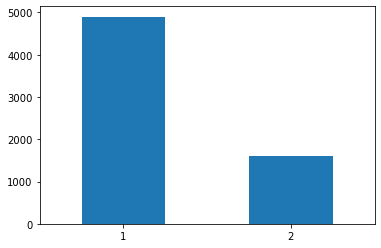

In [ ]:
value_counts = pd.value_counts(df['wine_codificado'],sort=True)
value_counts.plot(kind="bar",rot=0)
plt.show()

In [ ]:
from imblearn.combine import SMOTETomek

In [ ]:
bald_datos= SMOTETomek(sampling_strategy=0.8, random_state=2021)

In [ ]:
x_train_bal, y_train_bal=bald_datos.fit_resample(x_train,y_train)

In [ ]:
train_bal= pd.concat([x_train_bal, y_train_bal],axis=1)
train_bal.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_codificado
0,7.7,0.34,0.58,11.1,0.039,41.0,151.0,0.99780,3.06,0.49,8.6,1
1,6.0,0.27,0.32,3.6,0.035,36.0,133.0,0.99215,3.23,0.46,10.8,1
2,6.4,0.28,0.19,5.4,0.042,67.0,181.0,0.99435,3.31,0.35,10.2,1
3,5.2,0.37,0.33,1.2,0.028,13.0,81.0,0.99020,3.37,0.38,11.7,1
4,6.9,0.25,0.47,8.4,0.042,36.0,156.0,0.99604,3.15,0.55,9.4,1


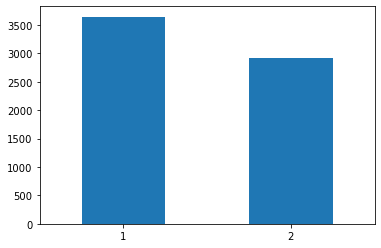

In [ ]:
value_counts = pd.value_counts(train_bal['wine_codificado'],sort=True)
value_counts.plot(kind="bar",rot=0)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  wine_type             6497 non-null   object 
 12  wine_codificado       6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
y_train

3731    1
1651    1
5060    1
1303    1
474     1
       ..
4931    2
3264    2
1653    1
2607    1
2732    1
Name: wine_codificado, Length: 4872, dtype: int64

In [ ]:
x_train_bal

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.700000,0.340000,0.580000,11.100000,0.039000,41.000000,151.000000,0.997800,3.060000,0.490000,8.600000
1,6.000000,0.270000,0.320000,3.600000,0.035000,36.000000,133.000000,0.992150,3.230000,0.460000,10.800000
2,6.400000,0.280000,0.190000,5.400000,0.042000,67.000000,181.000000,0.994350,3.310000,0.350000,10.200000
3,5.200000,0.370000,0.330000,1.200000,0.028000,13.000000,81.000000,0.990200,3.370000,0.380000,11.700000
4,6.900000,0.250000,0.470000,8.400000,0.042000,36.000000,156.000000,0.996040,3.150000,0.550000,9.400000
...,...,...,...,...,...,...,...,...,...,...,...
6547,11.500000,0.180000,0.510000,4.000000,0.104000,4.000000,23.000000,0.999600,3.280000,0.970000,10.100000
6548,9.243837,0.367176,0.384696,1.509360,0.080062,41.062403,55.156008,0.996472,3.458455,0.720328,10.846957
6549,7.374493,0.666345,0.409082,1.611353,0.090426,13.822706,95.468117,0.995444,3.257372,0.660778,10.120531
6550,6.324777,0.573975,0.085508,1.685027,0.053599,24.000000,32.049911,0.994089,3.526524,0.597504,11.220143


In [ ]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit_transform(x_train_bal)
scaler[[0]]

array([[ 0.12186049, -0.26969067,  1.76102106,  1.49464226, -0.64589223,
         0.84129136,  0.89569449,  0.90256544, -1.1310601 , -0.48400088,
        -1.65266046]])

In [ ]:
logit_model = LogisticRegression()
logit_model.fit(scaler, y_train_bal)

LogisticRegression()

In [ ]:
logit_model.score(scaler, y_train_bal)

0.9952686202686203

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_bal, logit_model.predict_proba(scaler)[:, 1])

0.9980023565964271

In [ ]:
scaler_test = preprocessing.StandardScaler().fit_transform(x_test)


In [ ]:
logit_model.score(scaler_test,y_test)

0.9698461538461538

In [ ]:
prob_test= logit_model.predict_proba(scaler_test)
prob_test[0]

array([0.95216304, 0.04783696])

In [ ]:
df_prob = pd.DataFrame(prob_test,columns=['1','2'])

In [ ]:
punto = 0.6

In [ ]:
df_prob["predict"]=np.where(df_prob["2"]>punto,2,1)

In [ ]:
y_test

5316    1
5210    1
3518    1
1622    1
2443    2
       ..
2152    1
4019    2
3732    1
1315    2
5701    1
Name: wine_codificado, Length: 1625, dtype: int64

In [ ]:
df_prob

,1,2,predict
0,0.952163,0.047837,1
1,0.976731,0.023269,1
2,0.961004,0.038996,1
3,0.998009,0.001991,1
4,0.005235,0.994765,2
...,...,...,...
1620,0.990162,0.009838,1
1621,0.000006,0.999994,2
1622,0.997572,0.002428,1
1623,0.000003,0.999997,2


In [ ]:
from sklearn import metrics
metrics.accuracy_score(y_test,df_prob["predict"])

0.9790769230769231

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test, df_prob["predict"])

array([[1198,   32],
       [   2,  393]])

In [ ]:
VN, FP, FN, VP = confusion_matrix([0, 1, 0, 1], [1, 1, 1, 0]).ravel()

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
y_test.count()

1625

In [ ]:
VN = 1198
VP = 393
FN= 32
FP = 2

In [ ]:
sensibilidad= VP/(VP+FN)
sensibilidad

0.9247058823529412

In [ ]:
especificidad= VN/(VN+FP)
especificidad

0.9983333333333333

In [ ]:
(especificidad+sensibilidad)/2

0.9615196078431372

In [ ]:
Acc= (VP+VN)/(VP+VN+FP+FN)
Acc

0.9790769230769231

In [ ]:
espc_roc= 1-especificidad
espc_roc

0.0016666666666667052

Text(0.5, 1.0, 'Curva ROC')

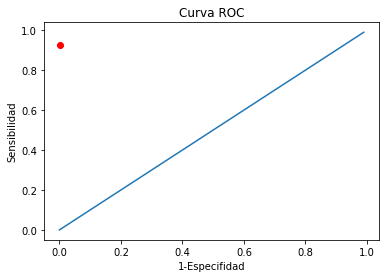

In [ ]:
plt.plot(espc_roc, 
         sensibilidad, 
         marker="o", 
         linestyle="--", 
         color="red")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

## Discriminante Lineal

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, precision_score

In [ ]:
lda=LinearDiscriminantAnalysis()
model_lda=lda.fit(scaler, y_train_bal)

In [ ]:
print(model_lda.priors_)
print(model_lda.means_)
print(model_lda.coef_)

[0.55601343 0.44398657]
[[-0.4536137  -0.59885452  0.17740998  0.40266358 -0.47870468  0.50710247
   0.68711372 -0.43438441 -0.3422296  -0.48391633  0.04270017]
 [ 0.56806968  0.74995773 -0.22217414 -0.50426381  0.59949163 -0.63505476
  -0.86048652  0.54398845  0.4285811   0.60601829 -0.0534743 ]]
[[ -4.28957044   3.01125647  -0.46607297 -10.04113564   0.68041827
    1.78787232  -6.89910161  17.13283231  -1.46611993   0.83266346
    6.23937326]]


In [ ]:
pred=model_lda.predict(scaler_test)

In [ ]:
pred

array([1, 1, 1, ..., 1, 2, 1])

In [ ]:
print(np.unique(pred, return_counts=True))

(array([1, 2]), array([1205,  420]))


In [ ]:
print(confusion_matrix(pred, y_test)) 

[[1203    2]
 [  27  393]]


## Discriminante cuadratico

In [ ]:
qda = QuadraticDiscriminantAnalysis()
model2 = qda.fit(scaler, y_train_bal)

In [ ]:
pred4=model2.predict(scaler_test)
print(np.unique(pred4, return_counts=True))  

(array([1, 2]), array([1150,  475]))


In [ ]:
print(classification_report(y_test, pred4, digits=3))

              precision    recall  f1-score   support

           1      0.998     0.933     0.965      1230
           2      0.827     0.995     0.903       395

    accuracy                          0.948      1625
   macro avg      0.913     0.964     0.934      1625
weighted avg      0.957     0.948     0.950      1625



In [ ]:
pred = model2.predict(scaler_test)

In [ ]:
confusion_matrix(y_test, pred)

array([[1148,   82],
       [   2,  393]])

In [ ]:
VN2 = 1148
VP2 = 393
FN2= 82
FP2 = 2

In [ ]:
sensibilidad2= VP2/(VP2+FN2) 
sensibilidad2

0.8273684210526315

In [ ]:
especificidad2= VN2/(VN2+FP2)
especificidad2

0.9982608695652174

In [ ]:
Acc2= (VP2+VN2)/(VP2+VN2+FP2+FN2)
Acc2

0.9483076923076923

In [ ]:
espc_roc2= 1-especificidad2
espc_roc2

0.0017391304347825765

Text(0.5, 1.0, 'Curva ROC')

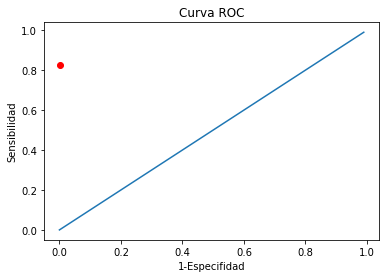

In [ ]:
plt.plot(espc_roc2, 
         sensibilidad2, 
         marker="o", 
         linestyle="--", 
         color="red")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

# Evaluacion de los 3 modelos

In [ ]:
evaluacion = pd.DataFrame(columns=['nombre','logistic','discriminante lineal','discriminante cuadratico'])

In [ ]:
logistic = logit_model.predict(scaler_test)
lineal = model_lda.predict(scaler_test)
cuadratico =model2.predict(scaler_test)
print(classification_report(y_test, logistic, digits=3))
print(classification_report(y_test, lineal, digits=3))
print(classification_report(y_test, cuadratico, digits=3))

              precision    recall  f1-score   support

           1      0.998     0.962     0.980      1230
           2      0.893     0.995     0.941       395

    accuracy                          0.970      1625
   macro avg      0.946     0.978     0.961      1625
weighted avg      0.973     0.970     0.970      1625

              precision    recall  f1-score   support

           1      0.998     0.978     0.988      1230
           2      0.936     0.995     0.964       395

    accuracy                          0.982      1625
   macro avg      0.967     0.986     0.976      1625
weighted avg      0.983     0.982     0.982      1625

              precision    recall  f1-score   support

           1      0.998     0.933     0.965      1230
           2      0.827     0.995     0.903       395

    accuracy                          0.948      1625
   macro avg      0.913     0.964     0.934      1625
weighted avg      0.957     0.948     0.950      1625



In [ ]:
sbL= 1198/(1198+32)
sbDL=1203/(1203+2)
sbDC=1148/(1148+82)

In [ ]:
evaluacion['nombre'] = ['accuracy','precision 1', 'precision 2','sensibilidad']
evaluacion['logistic']=[0.970, 0.998, 0.893, sbL]
evaluacion['discriminante lineal']=[0.982, 0.998, 0.936, sbDL]
evaluacion['discriminante cuadratico']=[0.948,0.998, 0.827, sbDC]

In [ ]:
evaluacion

,nombre,logistic,discriminante lineal,discriminante cuadratico
0,accuracy,0.970000,0.98200,0.948000
1,precision 1,0.998000,0.99800,0.998000
2,precision 2,0.893000,0.93600,0.827000
3,sensibilidad,0.973984,0.99834,0.933333
